# Explore the space around a fiber segment to look where the fiber can 'see'

In [33]:
import pykonal 
from pykonal.transformations import geo2sph, sph2geo
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr 
from tqdm import tqdm

import numpy as np 
import pandas as pd 
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


import sys
import os

sys.path.append(os.path.abspath("../src"))
from fct_DAS_sensitivity import *

# 1. Load travel time grid 
made in first notebook 

In [3]:
folder = r'C:\Users\liliv\Desktop\DAS_senstivity\test'

In [4]:
# Pykonal specific

latitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['latitude'].values
longitudes = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['longitude'].values
depths = xr.load_dataarray(glob.glob(folder+'//*')[0]).coords['depth'].values

# node spacing
grid_spacing = (
    np.abs(depths[1] - depths[0]),
    np.deg2rad(np.abs(latitudes[1] - latitudes[0])),
    np.deg2rad(np.abs(longitudes[1] - longitudes[0])),)

# reference point (northest westest and deepest point of the grid)
reference_point = geo2sph((latitudes.max(), longitudes.min(), depths.max()))

travel_times = xr.load_dataarray(glob.glob(folder+'/*')[0])

# give the shape of your grid, here use the first grid of dataset and extract variable 
model_shape = travel_times.transpose( 'depth','latitude', 'longitude').values.shape

### Initialize the solver once with constant grid settings ###

solver = pykonal.solver.PointSourceSolver(coord_sys="spherical")
# Set up grid properties
solver.velocity.min_coords = reference_point
solver.velocity.node_intervals = grid_spacing
solver.velocity.npts = model_shape  # Ensure shape matches the travel time grid


# Create DataFrame to hold results 
result_container = pd.DataFrame()

# Create a list with all channel names to load travel times grids one after the other
all_files = glob.glob(folder+'//*')
number_only = [int(number.split('\\')[-1].split('.')[0]) for number in all_files]
number_only = sorted(number_only)

# Ensure the travel time grid is set correctly in the solver
solver.tt.values = travel_times.transpose('depth', 'latitude', 'longitude').values  # Adjust dimensions if needed


# 2. DAS fiber parameters 

In [5]:
### path to station info ###
file_name = 'One_channel'
station_info_path = os.path.abspath("../Data/DAS_arrays/U_square/{}.csv".format(file_name))
station_info = pd.read_csv(station_info_path, sep = ',', index_col =0)

In [21]:
das = DASSensor(
    azimuth=0,
    dip=90,
    gauge_length=None,
    wavelength=None,
    velocity=None, 
    latitude = station_info.lat.values[0],
    longitude = station_info.lon.values[0],
    depth = station_info.depth.values[0],
)

In [27]:
wave_type = 'P'
min_distance = 0.0

# 3. get sensitivity to all node in space

In [28]:
# Cube resolution
n_lat = 10
n_lon = 10
n_depth = 10

In [29]:
output = xr.DataArray(
        np.zeros((n_lat, n_lon, n_depth)),
        coords={
            "latitude": np.linspace(travel_times.coords['latitude'].min(), travel_times.coords['latitude'].max(), n_lat),
            "longitude": np.linspace(travel_times.coords['longitude'].min(), travel_times.coords['longitude'].max(), n_lat),
            "depth": np.linspace(travel_times.coords['depth'].min(), travel_times.coords['depth'].max(), n_lat),
        },
        dims=("latitude", "longitude", "depth"),
    )


In [30]:
num_elements = output.values.size
for idx in tqdm(range(num_elements)):
        i, j, k = np.unravel_index(idx, output.values.shape)
        lat = output.coords['latitude'][i]
        lon = output.coords['longitude'][j]
        depth = output.coords['depth'][k]
        #try:
        # trace ray 
        d = distance_3d_km(lat1=das.values()[0], lon1=das.values()[1], depth1_km=das.values()[2],lat2=lat, lon2=lon, depth2_km=depth)
        # 1) if source and receiver to close => take a straight ray 
        if d<= min_distance:
                lats = np.linspace(das.values()[0],lat, 200 ) # ° latitude (N)
                lons = np.linspace(das.values()[1],lon, 200 ) # ° longitude (E)
                depth = np.linspace (das.values()[2],depth, 200) # km of depth
                ray = np.array([lats, lons, depth])
                ray = Ray(geo2sph(ray.T))

        # 2) if source revceiver far enough => use ttime to run ray tracing 
        else:
                end = np.array(geo2sph(np.array([lat, lon, depth])).squeeze()) 
                ray_nodes = solver.trace_ray(end)
                # Pykonal returns a ray without the source and receiver node. We add them back in this line 
                # first node is at the DAS and last node at the source
                ray_nodes = np.vstack([np.array(geo2sph(das.values()).squeeze()),ray_nodes, end ])
                ray = Ray(ray_nodes)
        
        az_ray_DAS, dip_ray_DAS = ray.azimuth_and_dip('DAS', 10)
        output.values[i,j,k] =  das.sensitivity(wave_type, az_ray_DAS, dip_ray_DAS)
        #except Exception as e:
                #output.values[i,j,k] = np.nan 

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [02:36<00:00,  6.39it/s]


C:\Users\liliv\AppData\Local\Temp\ipykernel_19900\3105586677.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("seismic")


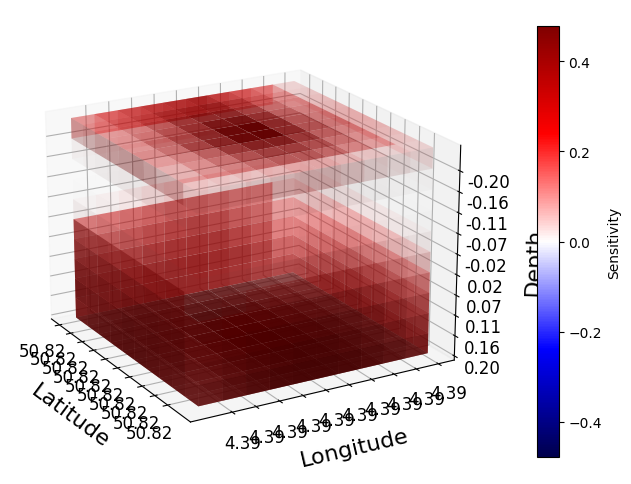

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# --------------------------------------------------
# Use values + coordinates directly from xarray DataArray
# --------------------------------------------------

# Example:
# output dims = ("latitude", "longitude", "depth")

data = output.values.copy()

# Clean invalid values
data[np.isinf(data)] = 0
data[np.isnan(data)] = 0

# Optional: reverse depth axis for plotting
data = data[:, :, ::-1]

# Coordinates from xarray
lat = output.coords["latitude"].values
lon = output.coords["longitude"].values
depth = output.coords["depth"].values[::-1]  # reversed to match data flip

# --------------------------------------------------
# Color normalization (diverging colormap)
# --------------------------------------------------

vmax = np.nanmax(np.abs(data))
vmin = -vmax

norm_data = (data - vmin) / (vmax - vmin)

# Transparency from amplitude
alpha = (np.abs(data) / vmax) ** 1.5

cmap = cm.get_cmap("seismic")
colors = cmap(norm_data)
colors[..., -1] = alpha

# Only show non-zero values
threshold = 0.0
filled = np.abs(data) > threshold * vmax

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

ax.voxels(
    filled,
    facecolors=colors,
    edgecolors=None
)

# --------------------------------------------------
# Use REAL xarray coordinates as axis labels
# --------------------------------------------------

ax.set_xticks(np.arange(len(lat)))
ax.set_yticks(np.arange(len(lon)))
ax.set_zticks(np.arange(len(depth)))

ax.set_xticklabels([f"{x:.2f}" for x in lat], fontsize=12)
ax.set_yticklabels([f"{y:.2f}" for y in lon], fontsize=12)
ax.set_zticklabels([f"{z:.2f}" for z in depth], fontsize=12)

ax.set_xlabel("Latitude", fontsize=16, labelpad=10)
ax.set_ylabel("Longitude", fontsize=16, labelpad=10)
ax.set_zlabel("Depth", fontsize=16, labelpad=10)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="z", labelsize=12)

ax.invert_yaxis()

ax.view_init(20, -30)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------

mappable = cm.ScalarMappable(
    cmap="seismic",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
mappable.set_array(data)

plt.colorbar(
    mappable,
    ax=ax,
    shrink=0.7,
    pad=0.1,
    label="Sensitivity"
)

plt.show()